The currently used device: cuda


100%|██████████| 792M/792M [00:53<00:00, 14.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.59MB/s]


The dataset has been loaded successfully!,have 37 categories.
Training set size: 3680, Test set size: 3669


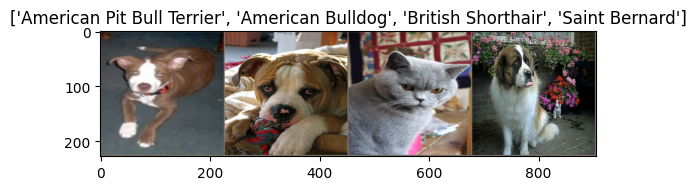

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. Set up the device (check if the GPU is connected)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The currently used device: {device}")

# 2. Define data preprocessing ( Resize and Normalize)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Download and load the dataset (Oxford-IIIT Pet dataset)
train_dataset = datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform_train)
test_dataset = datasets.OxfordIIITPet(root='./data', split='test', download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Number of categories
num_classes = len(train_dataset.classes)
print(f"The dataset has been loaded successfully!,have {num_classes} categories.")
print(f"Training set size: {len(train_dataset)}, Test set size: {len(test_dataset)}")

# 4. Visualize a simple picture
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[train_dataset.classes[x] for x in classes[:4]])

In [2]:
import time
import copy

# 5. Defining model (Baseline: ResNet18)
# Use pre-trained weights(Transfer Learning)
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify the last layer (category header) to fit our 37 pet categories
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, 37)
model_resnet = model_resnet.to(device)

# 6. Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
# Using the Adam optimizer, the learning rate is set to 0.001
optimizer = optim.Adam(model_resnet.parameters(), lr=0.001)

# 7. Training functions
def train_model(model, criterion, optimizer, num_epochs=5):
    since = time.time()

    # Data used for recording curves
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Training and validation stage
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
                dataset_size = len(train_dataset)
            else:
                model.eval()
                dataloader = test_loader
                dataset_size = len(test_dataset)

            running_loss = 0.0
            running_corrects = 0

            # Traverse the data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Gradient zeroing
                optimizer.zero_grad()

                # Forward propagation
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backpropagation and optimization
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Record historical data
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            # Deep copy the best-performing model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'The training is completed, but it takes a long time: {time_elapsed // 60:.0f}minutes {time_elapsed % 60:.0f}seconds')
    print(f'Best Val Acc: {best_acc:4f}')

    # Load the best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Begin training( 5 epochs)
best_resnet, resnet_history = train_model(model_resnet, criterion, optimizer, num_epochs=5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


Epoch 1/5
----------
Train Loss: 1.4548 Acc: 0.5736
Val Loss: 1.9772 Acc: 0.4451

Epoch 2/5
----------
Train Loss: 0.7500 Acc: 0.7701
Val Loss: 1.7433 Acc: 0.5181

Epoch 3/5
----------
Train Loss: 0.4601 Acc: 0.8590
Val Loss: 1.5115 Acc: 0.5838

Epoch 4/5
----------
Train Loss: 0.3121 Acc: 0.9022
Val Loss: 1.3288 Acc: 0.6440

Epoch 5/5
----------
Train Loss: 0.2276 Acc: 0.9310
Val Loss: 1.5685 Acc: 0.5819

The training is completed, but it takes a long time: 3minutes 11seconds
Best Val Acc: 0.644045


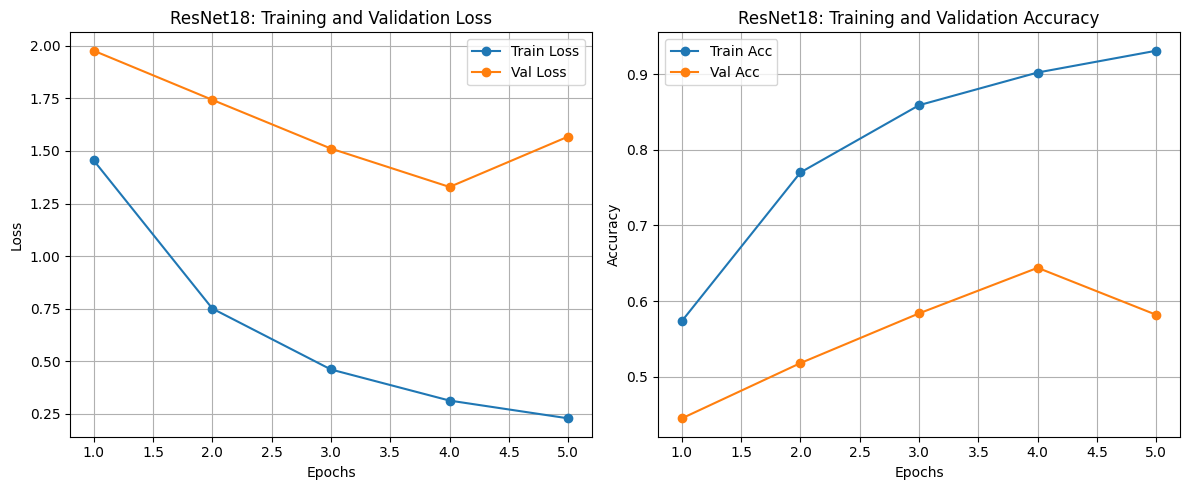

In [3]:
# 8. Plot the Loss and Accuracy curves of ResNet18
epochs = range(1, 6)

plt.figure(figsize=(12, 5))

# Draw the Loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs, resnet_history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs, resnet_history['val_loss'], label='Val Loss', marker='o')
plt.title('ResNet18: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot the Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs, resnet_history['train_acc'], label='Train Acc', marker='o')
plt.plot(epochs, resnet_history['val_acc'], label='Val Acc', marker='o')
plt.title('ResNet18: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
# 9. Define the contrast model (MobileNetV3) for horizontal comparison
model_mobilenet = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)

# Modify the category header of MobileNetV3
num_ftrs_mb = model_mobilenet.classifier[3].in_features
model_mobilenet.classifier[3] = nn.Linear(num_ftrs_mb, 37)
model_mobilenet = model_mobilenet.to(device)

# Define the optimizer
optimizer_mb = optim.Adam(model_mobilenet.parameters(), lr=0.001)

# Start training MobileNetV3 ( 5 epochs)
best_mobilenet, mobilenet_history = train_model(model_mobilenet, criterion, optimizer_mb, num_epochs=5)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 139MB/s]


Epoch 1/5
----------
Train Loss: 1.0969 Acc: 0.6755
Val Loss: 1.2002 Acc: 0.6838

Epoch 2/5
----------
Train Loss: 0.4118 Acc: 0.8663
Val Loss: 1.0781 Acc: 0.7089

Epoch 3/5
----------
Train Loss: 0.2665 Acc: 0.9114
Val Loss: 1.3209 Acc: 0.6833

Epoch 4/5
----------
Train Loss: 0.2496 Acc: 0.9236
Val Loss: 1.1538 Acc: 0.7236

Epoch 5/5
----------
Train Loss: 0.2041 Acc: 0.9345
Val Loss: 1.1929 Acc: 0.7185

The training is completed, but it takes a long time: 3minutes 6seconds
Best Val Acc: 0.723630


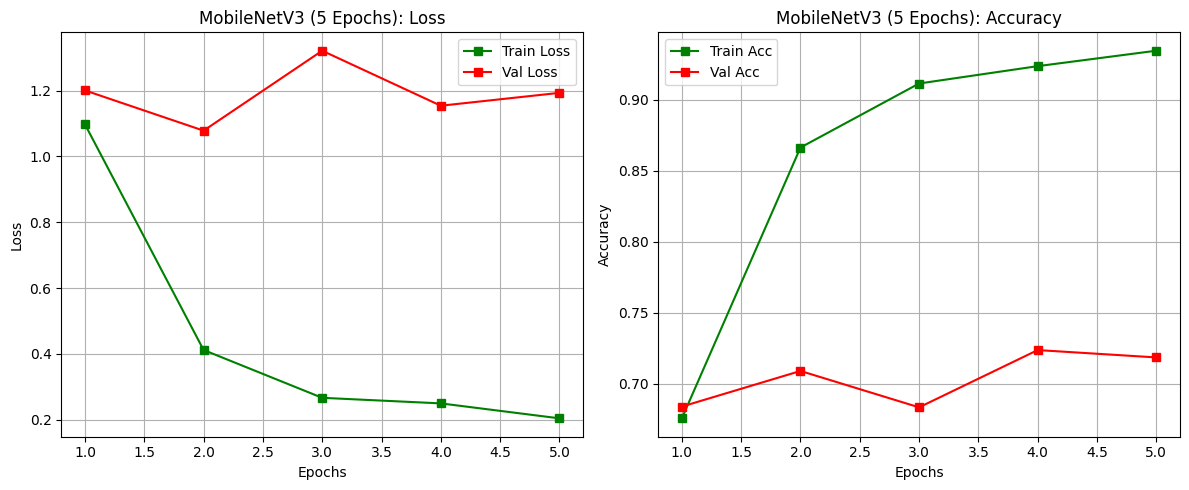

In [5]:
# Plot the Loss and Accuracy curves of MobileNetV3-Large (5 Epochs baseline)
epochs_mb = range(1, 6)

plt.figure(figsize=(12, 5))

# Draw the Loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs_mb, mobilenet_history['train_loss'], label='Train Loss', marker='s', color='green')
plt.plot(epochs_mb, mobilenet_history['val_loss'], label='Val Loss', marker='s', color='red')
plt.title('MobileNetV3 (5 Epochs): Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot the Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs_mb, mobilenet_history['train_acc'], label='Train Acc', marker='s', color='green')
plt.plot(epochs_mb, mobilenet_history['val_acc'], label='Val Acc', marker='s', color='red')
plt.title('MobileNetV3 (5 Epochs): Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Improvement plan: Introduce Data Augmentation to alleviate overfitting

# Define enhancement strategies: random cropping, horizontal flipping, and color fine-tuning
transform_train_aug = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Reload the training set (a new transform is used here)
train_dataset_aug = datasets.OxfordIIITPet(root='./data', split='trainval', download=False, transform=transform_train_aug)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True, num_workers=2)

# Reinitialize the MobileNetV3 model
model_mobilenet_aug = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
num_ftrs_mb = model_mobilenet_aug.classifier[3].in_features
model_mobilenet_aug.classifier[3] = nn.Linear(num_ftrs_mb, 37)
model_mobilenet_aug = model_mobilenet_aug.to(device)

# Define the optimizer
optimizer_mb_aug = optim.Adam(model_mobilenet_aug.parameters(), lr=0.001)

# Modify the training function to accept a specific loader
def train_model_custom_loader(model, train_loader, test_loader, criterion, optimizer, num_epochs=5):
    best_acc = 0.0
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
                dataset_size = len(train_loader.dataset)
            else:
                model.eval()
                dataloader = test_loader
                dataset_size = len(test_loader.dataset)

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
        print()
    print(f'Best Val Acc of the enhanced maximum validation set): {best_acc:4f}')
    return model

# Run the enhanced model
best_mobilenet_aug = train_model_custom_loader(model_mobilenet_aug, train_loader_aug, test_loader, criterion, optimizer_mb_aug, num_epochs=5)

Epoch 1/5
----------
Train Loss: 1.5231 Acc: 0.5587
Val Loss: 1.3776 Acc: 0.5923

Epoch 2/5
----------
Train Loss: 1.0013 Acc: 0.6918
Val Loss: 1.2623 Acc: 0.6490

Epoch 3/5
----------
Train Loss: 0.8541 Acc: 0.7334
Val Loss: 1.2035 Acc: 0.6994

Epoch 4/5
----------
Train Loss: 0.7658 Acc: 0.7658
Val Loss: 1.1162 Acc: 0.6833

Epoch 5/5
----------
Train Loss: 0.7091 Acc: 0.7853
Val Loss: 1.2972 Acc: 0.6901

Best Val Acc of the enhanced maximum validation set): 0.699373


Only 5 epochs were used for training before, and comparisons were made. Finally, the number of epochs was increased

Epoch 1/20
----------
Train Loss: 1.5372 Acc: 0.5647
Val Loss: 1.7578 Acc: 0.5249

Epoch 2/20
----------
Train Loss: 0.9952 Acc: 0.6902
Val Loss: 1.2007 Acc: 0.6678

Epoch 3/20
----------
Train Loss: 0.8209 Acc: 0.7429
Val Loss: 0.8911 Acc: 0.7204

Epoch 4/20
----------
Train Loss: 0.7079 Acc: 0.7845
Val Loss: 0.9771 Acc: 0.7086

Epoch 5/20
----------
Train Loss: 0.6616 Acc: 0.7943
Val Loss: 0.9790 Acc: 0.7465

Epoch 6/20
----------
Train Loss: 0.6073 Acc: 0.8174
Val Loss: 1.0604 Acc: 0.7133

Epoch 7/20
----------
Train Loss: 0.5255 Acc: 0.8405
Val Loss: 0.9313 Acc: 0.7383

Epoch 8/20
----------
Train Loss: 0.4863 Acc: 0.8481
Val Loss: 0.8738 Acc: 0.7771

Epoch 9/20
----------
Train Loss: 0.4292 Acc: 0.8674
Val Loss: 0.7644 Acc: 0.7931

Epoch 10/20
----------
Train Loss: 0.3907 Acc: 0.8783
Val Loss: 0.7367 Acc: 0.7956

Epoch 11/20
----------
Train Loss: 0.3409 Acc: 0.8908
Val Loss: 0.7796 Acc: 0.7874

Epoch 12/20
----------
Train Loss: 0.3054 Acc: 0.9046
Val Loss: 0.6544 Acc: 0.8215

E

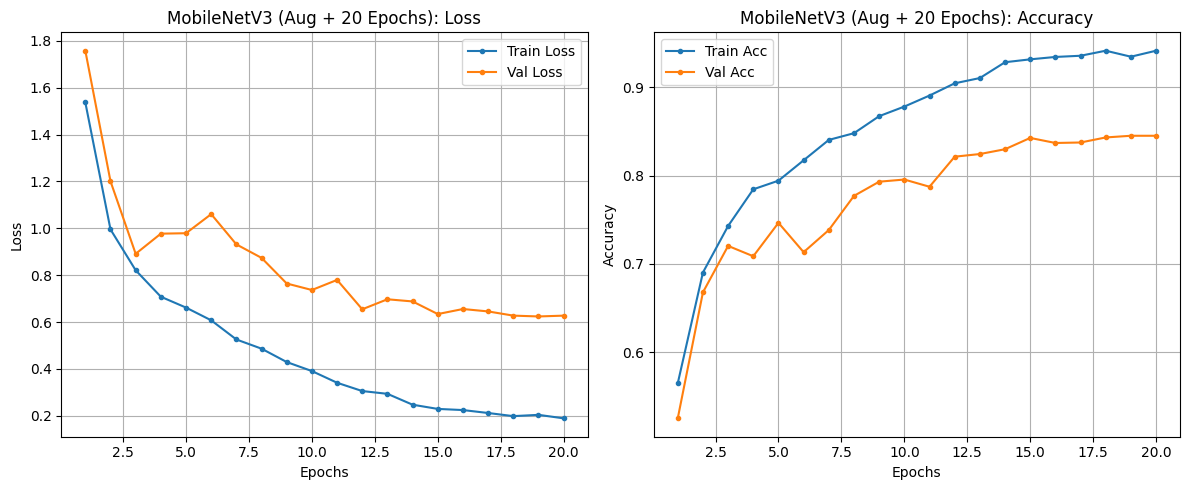

In [7]:
# 11. Final solution: Data augmentation + increasing epochs (20) + learning rate attenuation (Cosine Annealing)
import time
import copy
import torch.optim.lr_scheduler as lr_scheduler

model_mobilenet_aug_long = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
num_ftrs_mb = model_mobilenet_aug_long.classifier[3].in_features
model_mobilenet_aug_long.classifier[3] = nn.Linear(num_ftrs_mb, 37)
model_mobilenet_aug_long = model_mobilenet_aug_long.to(device)

# Define the optimizer
optimizer_mb_aug_long = optim.Adam(model_mobilenet_aug_long.parameters(), lr=0.001)

# Core new addition: Learning Rate Scheduler. Cosine Annealing is used to smoothly reduce the learning rate to 0 within 20 epochs
scheduler = lr_scheduler.CosineAnnealingLR(optimizer_mb_aug_long, T_max=20)

# A long-range training function with history and Scheduler
def train_model_long(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs=20):
    since = time.time()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
                dataset_size = len(train_loader.dataset)
            else:
                model.eval()
                dataloader = test_loader
                dataset_size = len(test_loader.dataset)

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Record history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                scheduler.step()
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            # Save the best model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Training completed!: {time_elapsed // 60:.0f}minutes {time_elapsed % 60:.0f}seconds')
    print(f' 20 Epochs Best Val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# Start running the model
best_mobilenet_long, history_long = train_model_long(
    model_mobilenet_aug_long, train_loader_aug, test_loader, criterion, optimizer_mb_aug_long, scheduler, num_epochs=20
)

# --- Draw a training curve of 20 Epochs ---
epochs_long = range(1, 21)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_long, history_long['train_loss'], label='Train Loss', marker='.')
plt.plot(epochs_long, history_long['val_loss'], label='Val Loss', marker='.')
plt.title('MobileNetV3 (Aug + 20 Epochs): Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_long, history_long['train_acc'], label='Train Acc', marker='.')
plt.plot(epochs_long, history_long['val_acc'], label='Val Acc', marker='.')
plt.title('MobileNetV3 (Aug + 20 Epochs): Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()